# Regresión Logística: Stratified K-Fold, Métricas y Calibración del Modelo

La primera parte de este notebook replica el contenido del notebook '4.Regresión_logística_Desinformación'. En esta sección, se importarán las librerías necesarias, se cargará y realizará la exploración y limpieza del dataset. Posteriormente, se ejecutará el modelo de regresión logística, mostrando sus métricas y resultados.

La segunda parte se enfocará en la validación cruzada utilizando Stratified K-Fold, la creación de gráficos y la obtención de métricas (ROC, recall y diagrama de calibración).

Finalmente, se obtendrán las métricas de calibración (Brier Score) y la métrica de clasificación de Umbral Óptimo.

## Librerias


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import drive
from imblearn.pipeline import Pipeline
# ML models
from sklearn.linear_model import LogisticRegression
# scikit-learn:
from sklearn.metrics import confusion_matrix
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    roc_curve, auc, precision_recall_curve, average_precision_score,
    brier_score_loss, classification_report
)

## Carga DataFrame

In [ ]:
#Montar drive
drive.mount('/content/drive')

In [ ]:
#Ruta del archivo en Drive
content_path = "/content/drive/MyDrive/Proyecto grado/Codigo/ML/Aleatorizacion-DataSetCompleto (1) (1).xlsx"

# Ruta preCargada en Colab
content_path = '/content/Aleatorizacion-DataSetCompleto (1) (1)-2.xlsx'

In [ ]:
#leer df
df_clasificado = pd.read_excel(content_path)
print(df_clasificado.sample(8))

      categoría            id              page_name  \
3629          4  1.220000e+15           Felipe Vélez   
139           2  1.130000e+15     Todos por Medellín   
12            1  3.645990e+15     Todos por Medellín   
3129          4  6.810000e+15         Fico Gutiérrez   
361           3  1.010000e+15  Juan David Valderrama   
2651          4  8.802892e+14     Juan Carlos Upegui   
1041          3  6.640161e+14           Felipe Vélez   
2698          4  1.070000e+15     Juan Carlos Upegui   

                                   transcripcion_pg_ext  \
3629  ['¡Sí se puede! @medellinvuelveabrillar\n\n#Fe...   
139   ['Nos fuimos para el centro de la ciudad a pre...   
12     Apuesto por una Medellín segura, por una Mede...   
3129  ['El 29 de octubre vota Fico y Creemos Equipo ...   
361   Queremos hacer una estrategia de recicladores ...   
2651  ['El Metro será gratuito para jóvenes y person...   
1041  He sido empresario toda mi vida. Yo fui tambié...   
2698  ['Vamos a seguir 

### Exploracion de los datos

In [ ]:
# tamaño
df_clasificado.shape

(3732, 18)

In [ ]:
df_clasificado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3732 entries, 0 to 3731
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   categoría             3732 non-null   int64  
 1   id                    3732 non-null   float64
 2   page_name             3732 non-null   object 
 3   transcripcion_pg_ext  3732 non-null   object 
 4   trans_clean           3722 non-null   object 
 5   token_text            3732 non-null   object 
 6   Hate Speech           3732 non-null   int64  
 7   prob_emoción          3732 non-null   float64
 8   emocion               3732 non-null   object 
 9   prob_sentimiento      3732 non-null   float64
 10  Groserias             3732 non-null   int64  
 11  menciones_binaria     3732 non-null   int64  
 12  prob_sentimiento.1    3732 non-null   int64  
 13  prob_emoción.1        3732 non-null   int64  
 14  Hate Speech.1         3732 non-null   int64  
 15  Groserias.1          

### Limpieza del df

In [ ]:
df_copy = df_clasificado.copy()

In [ ]:
# Eliminar columnas que no necesitamos
df_copy.drop(columns=[
    'page_name',
    'transcripcion_pg_ext',
    'token_text',
    'Hate Speech',
    'prob_sentimiento',
    'emocion',
    'prob_emoción',
    'Groserias',
    'menciones_binaria',
    'prob_sentimiento.1',
    'prob_emoción.1',
    'Hate Speech.1',
    'Groserias.1',
    'menciones_binaria.1'
], inplace=True)

In [ ]:
df_copy

,categoría,id,trans_clean,Prob_Fake
0,1,2.253500e+14,medellin operado entramado corrupcion presunta...,0
1,1,8.440730e+14,medellin cartel contratacion denunciamos forma...,1
2,1,2.751852e+14,recuerda hablado cartel contratacion medellin ...,0
3,1,8.677843e+14,medellin cartel contratacion denunciamos forma...,1
4,1,1.732190e+15,medellin operado entramado corrupcion presunta...,0
...,...,...,...,...
3727,4,8.023435e+14,medellin necesita nuevos liderazgos necesitamo...,0
3728,4,7.224310e+14,29 octubre votamos carlosballesterosalcalde ad...,0
3729,4,8.447881e+14,porfinunamedellindetodxs cada vez vamos transf...,0
3730,4,1.050000e+15,medellin vision relacion actores publicos priv...,0


In [ ]:
# verificar datos nullos
df_copy.isnull().sum()

,0
categoría,0
id,0
trans_clean,10
Prob_Fake,0


In [ ]:
#Eliminar datos nulos
df_copy.dropna(inplace=True)

In [ ]:
# tamaño del dataset luego de la limpieza de datos nulos o vacios
df_copy.shape

(3722, 4)

## Regresion Logistica

In [ ]:
# Preparar dataset de entrenamiento y validacion

# == Asignación variables ==
X = df_copy['trans_clean']
y = df_copy['Prob_Fake']


# == Dividir data de testeo y entrenamiento ==
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2,random_state=42) #20% del total de la data es para test


# == preparacion del conjunto de entrenamiento y del test ==
# Se importa y se instancia el vectorizador CountVectorizer (modelo Bag of Words)
vect = CountVectorizer()

# Se ajusta el vectorizador al texto de entrenamiento y se transforma en una matriz de términos
X_train_dtm = vect.fit_transform(X_train)

# Se transforma el texto de prueba utilizando el mismo vocabulario aprendido del entrenamiento
X_test_dtm = vect.transform(X_test)

# Se imprime la forma (número de documentos, número de palabras) de las matrices resultantes
print(X_train_dtm.shape, X_test_dtm.shape)

(2977, 7906) (745, 7906)


In [ ]:
# Regresión logística
model_2 = LogisticRegression(random_state=42)

# Entrena el modelo usando la matriz de términos del conjunto de entrenamiento y sus etiquetas
model_2.fit(X_train_dtm, y_train)


LogisticRegression(random_state=42)

In [ ]:
# Genera las predicciones del modelo en el conjunto de prueba
y_pred_2 = model_2.predict(X_test_dtm)

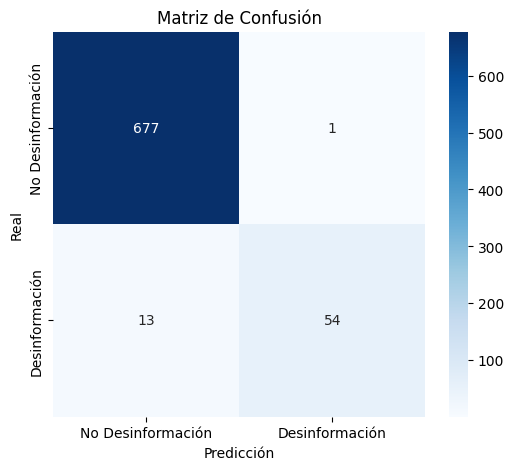

In [ ]:
# Calcular la matriz de confusión
cm = confusion_matrix(y_test, y_pred_2)

# Visualizar la matriz de confusión
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Desinformación', 'Desinformación'], yticklabels=['No Desinformación', 'Desinformación'])
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.savefig("matriz_confusion.png", dpi=300, bbox_inches="tight")

plt.show()


In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_2))

Accuracy: 0.9812080536912752


In [ ]:
print("Classification Report:\n", classification_report(y_test, y_pred_2))


Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99       678
           1       0.98      0.81      0.89        67

    accuracy                           0.98       745
   macro avg       0.98      0.90      0.94       745
weighted avg       0.98      0.98      0.98       745



# Validacion Cruzada

Metodo: **StratifiedKFold**

La variante que usaremos sera StratifiedKFold que es una versión mejorada del K-Fold estándar.

K-Fold estándar divide los datos en K partes de forma aleatoria, sin importar la distribución de clases. Stratified K-Fold hace lo mismo pero asegura que cada fold mantenga la misma proporción de clases que el dataset original.


In [ ]:
# == Asignación variables ==
X = df_copy['trans_clean']
y = df_copy['Prob_Fake']

# == Pipeline: vectorización + modelo ==
# Es CRUCIAL usar un Pipeline para que CountVectorizer se ajuste
# solo con los datos de entrenamiento en cada fold, evitando data leakage.
pipeline = Pipeline([
    ('vect', CountVectorizer()),
    ('clf', LogisticRegression(random_state=42))
])

# == Configuración de validación cruzada ==
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) # 5 folds por convencion estandar

In [ ]:
# == Ejecutar validación cruzada ==
scoring = ['accuracy', 'precision', 'recall', 'f1']

cv_results = cross_validate(
    pipeline, X, y,
    cv=cv,
    scoring=scoring,
    return_train_score=True
)

# == Resultados por fold ==
print("=" * 60)
print("VALIDACIÓN CRUZADA - Regresión Logística (5 Folds)")
print("=" * 60)

for metric in scoring:
    test_scores = cv_results[f'test_{metric}']
    train_scores = cv_results[f'train_{metric}']
    print(f"\n--- {metric.upper()} ---")
    for i, (train, test) in enumerate(zip(train_scores, test_scores)):
        print(f"  Fold {i+1}: Train = {train:.4f} | Test = {test:.4f}")
    print(f"  Media Test:  {test_scores.mean():.4f} ± {test_scores.std():.4f}")
    print(f"  Media Train: {train_scores.mean():.4f} ± {train_scores.std():.4f}")


VALIDACIÓN CRUZADA - Regresión Logística (5 Folds)

--- ACCURACY ---
  Fold 1: Train = 0.9970 | Test = 0.9678
  Fold 2: Train = 0.9973 | Test = 0.9745
  Fold 3: Train = 0.9956 | Test = 0.9852
  Fold 4: Train = 0.9973 | Test = 0.9772
  Fold 5: Train = 0.9960 | Test = 0.9812
  Media Test:  0.9772 ± 0.0059
  Media Train: 0.9966 ± 0.0007

--- PRECISION ---
  Fold 1: Train = 0.9963 | Test = 0.9245
  Fold 2: Train = 1.0000 | Test = 0.9310
  Fold 3: Train = 0.9962 | Test = 0.9531
  Fold 4: Train = 1.0000 | Test = 0.9815
  Fold 5: Train = 0.9962 | Test = 0.9661
  Media Test:  0.9513 ± 0.0213
  Media Train: 0.9977 ± 0.0018

--- RECALL ---
  Fold 1: Train = 0.9710 | Test = 0.7101
  Fold 2: Train = 0.9710 | Test = 0.7826
  Fold 3: Train = 0.9565 | Test = 0.8841
  Fold 4: Train = 0.9710 | Test = 0.7681
  Fold 5: Train = 0.9601 | Test = 0.8261
  Media Test:  0.7942 ± 0.0583
  Media Train: 0.9659 ± 0.0063

--- F1 ---
  Fold 1: Train = 0.9835 | Test = 0.8033
  Fold 2: Train = 0.9853 | Test = 0.8504
 

In [ ]:
# == Resumen final ==
print("\n" + "=" * 60)
print("RESUMEN")
print("=" * 60)
print(f"  Accuracy:  {cv_results['test_accuracy'].mean():.4f} ± {cv_results['test_accuracy'].std():.4f}")
print(f"  Precision: {cv_results['test_precision'].mean():.4f} ± {cv_results['test_precision'].std():.4f}")
print(f"  Recall:    {cv_results['test_recall'].mean():.4f} ± {cv_results['test_recall'].std():.4f}")
print(f"  F1-Score:  {cv_results['test_f1'].mean():.4f} ± {cv_results['test_f1'].std():.4f}")


RESUMEN
  Accuracy:  0.9772 ± 0.0059
  Precision: 0.9513 ± 0.0213
  Recall:    0.7942 ± 0.0583
  F1-Score:  0.8647 ± 0.0385


# Modelos Calibrados, Curvas ROC y Precision-Recall

Se entrenan dos versiones calibradas. Platt Scaling ajusta una función sigmoide sobre las probabilidades, funciona bien cuando la distorsión es suave. Isotónica es más flexible y no asume ninguna forma funcional, pero necesita más datos para evitar sobreajuste.


In [ ]:
# ============================================================
# 1. ENTRENAR MODELOS CALIBRADOS (Platt Scaling e Isotónica)
# ============================================================

# Modelo base (sin calibrar) - usa el pipeline ya definido
pipeline.fit(X_train, y_train)

# Platt Scaling (method='sigmoid')
cal_sigmoid = CalibratedClassifierCV(pipeline, method='sigmoid', cv=5)
cal_sigmoid.fit(X_train, y_train)

# Calibración Isotónica (method='isotonic')
cal_isotonic = CalibratedClassifierCV(pipeline, method='isotonic', cv=5)
cal_isotonic.fit(X_train, y_train)

# Obtener probabilidades de la clase positiva (Fake)
y_prob_base = pipeline.predict_proba(X_test)[:, 1]
y_prob_sigmoid = cal_sigmoid.predict_proba(X_test)[:, 1]
y_prob_isotonic = cal_isotonic.predict_proba(X_test)[:, 1]

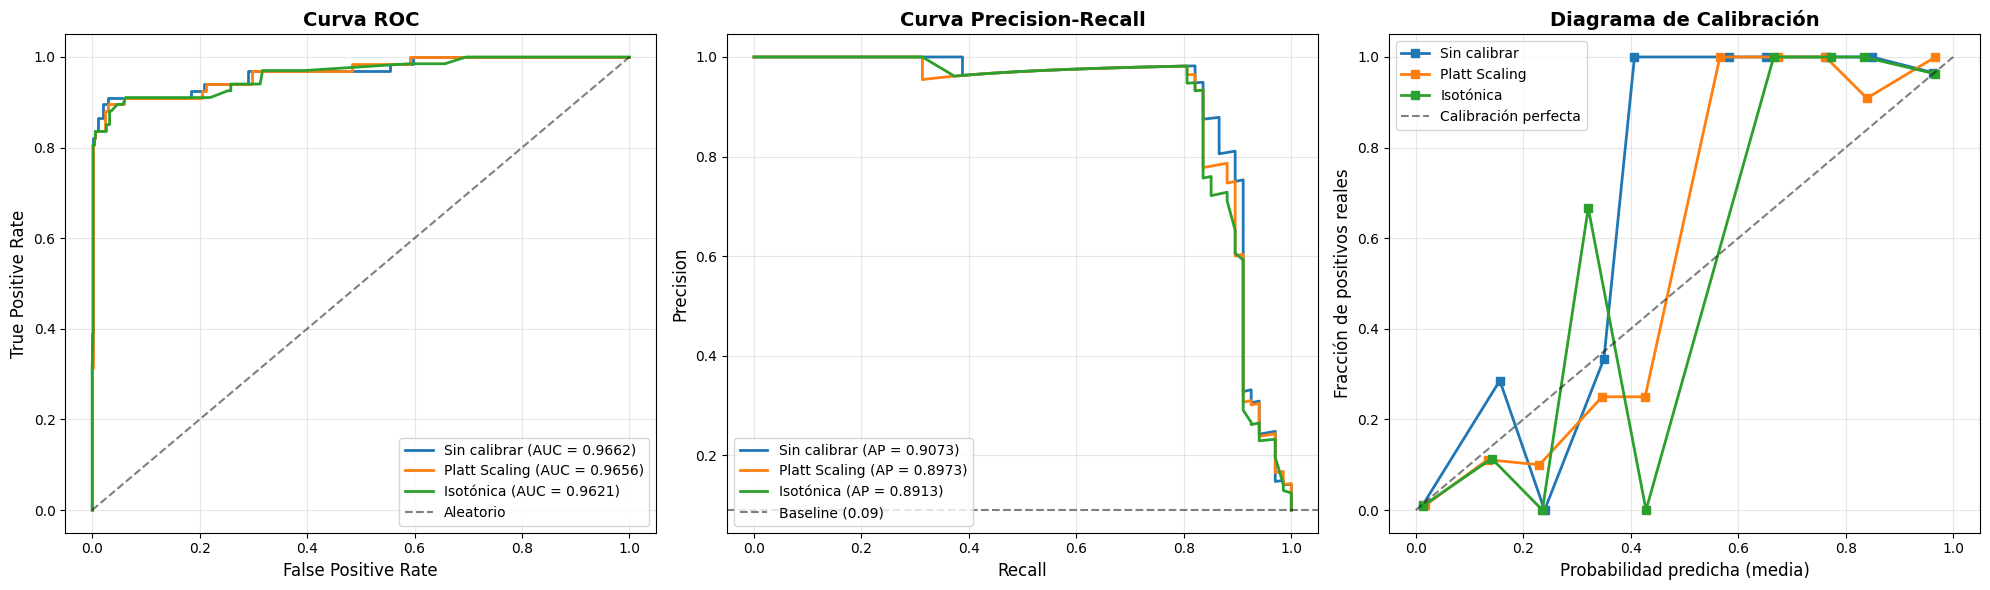

In [ ]:
# ============================================================
# 2. CURVA ROC, 3. CURVA PRECISION-RECALL, 4. DIAGRAMA DE CALIBRACIÓN
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

models = {
    'Sin calibrar': y_prob_base,
    'Platt Scaling': y_prob_sigmoid,
    'Isotónica': y_prob_isotonic
}

# --- ROC ---
ax = axes[0]
for name, y_prob in models.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC = {roc_auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Aleatorio')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('Curva ROC', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

# ============================================================
# 3. CURVA PRECISION-RECALL
# ============================================================

ax = axes[1]
for name, y_prob in models.items():
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    ax.plot(recall, precision, linewidth=2, label=f'{name} (AP = {ap:.4f})')

# Línea base: proporción de positivos
baseline = y_test.mean()
ax.axhline(y=baseline, color='k', linestyle='--', alpha=0.5, label=f'Baseline ({baseline:.2f})')
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Curva Precision-Recall', fontsize=14, fontweight='bold')
ax.legend(loc='lower left')
ax.grid(True, alpha=0.3)

# ============================================================
# 4. DIAGRAMA DE CALIBRACIÓN (Reliability Diagram)
# ============================================================

ax = axes[2]
for name, y_prob in models.items():
    fraction_pos, mean_predicted = calibration_curve(y_test, y_prob, n_bins=10, strategy='uniform')
    ax.plot(mean_predicted, fraction_pos, 's-', linewidth=2, label=name)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Calibración perfecta')
ax.set_xlabel('Probabilidad predicha (media)', fontsize=12)
ax.set_ylabel('Fracción de positivos reales', fontsize=12)
ax.set_title('Diagrama de Calibración', fontsize=14, fontweight='bold')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Brier Score

El Brier Score es una de las métricas más importantes, ya que evalúa la confiabilidad de las probabilidades predichas por el modelo, no solo su capacidad de acertar la clase (0 o 1).

Esta métrica es clave para la calibración: cuanto menor sea su valor, mejor calibradas estarán las probabilidades.

A continuación, compararemos los tres modelos para determinar cuál es el más adecuado.

In [ ]:
# ============================================================
# 5. MÉTRICAS DE CALIBRACIÓN (Brier Score)
# ============================================================

print("=" * 60)
print("MÉTRICAS DE CALIBRACIÓN (Brier Score - menor es mejor)")
print("=" * 60)

for name, y_prob in models.items():
    brier = brier_score_loss(y_test, y_prob)
    print(f"  {name:20s}: {brier:.4f}")

MÉTRICAS DE CALIBRACIÓN (Brier Score - menor es mejor)
  Sin calibrar        : 0.0182
  Platt Scaling       : 0.0205
  Isotónica           : 0.0200


# UMBRAL ÓPTIMO
En lugar de usar el umbral por defecto de 0.5, busca el umbral que maximiza el F1-Score para cada modelo. Esto puede mejorar significativamente el recall sin sacrificar demasiada precision.

In [ ]:

# ============================================================
# 6. ANÁLISIS POR UMBRAL ÓPTIMO (maximizar F1)
# ============================================================

print("\n" + "=" * 60)
print("UMBRAL ÓPTIMO (maximizando F1-Score)")
print("=" * 60)

for name, y_prob in models.items():
    precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
    # F1 para cada umbral (evitar división por cero)
    f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-10)
    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx]
    best_f1 = f1_scores[best_idx]

    # Predicciones con umbral óptimo
    y_pred_opt = (y_prob >= best_threshold).astype(int)

    print(f"\n--- {name} ---")
    print(f"  Umbral óptimo: {best_threshold:.4f}")
    print(f"  F1 con umbral óptimo: {best_f1:.4f}")
    print(f"\n  Classification Report (umbral = {best_threshold:.4f}):")
    print(classification_report(y_test, y_pred_opt, target_names=['Real', 'Fake']))


UMBRAL ÓPTIMO (maximizando F1-Score)

--- Sin calibrar ---
  Umbral óptimo: 0.4070
  F1 con umbral óptimo: 0.8943

  Classification Report (umbral = 0.4070):
              precision    recall  f1-score   support

        Real       0.98      1.00      0.99       678
        Fake       0.98      0.82      0.89        67

    accuracy                           0.98       745
   macro avg       0.98      0.91      0.94       745
weighted avg       0.98      0.98      0.98       745


--- Platt Scaling ---
  Umbral óptimo: 0.4144
  F1 con umbral óptimo: 0.8871

  Classification Report (umbral = 0.4144):
              precision    recall  f1-score   support

        Real       0.98      1.00      0.99       678
        Fake       0.96      0.82      0.89        67

    accuracy                           0.98       745
   macro avg       0.97      0.91      0.94       745
weighted avg       0.98      0.98      0.98       745


--- Isotónica ---
  Umbral óptimo: 0.6148
  F1 con umbral óptimo